In [1]:
import torch
import torch_geometric
print("PyTorch:", torch.__version__)
print("PyG:", torch_geometric.__version__)
print("✅ Environment is correct!")

PyTorch: 2.13.0+cpu
PyG: 2.8.0.post1
✅ Environment is correct!


In [2]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)

# Load IBM dataset
ibm = pd.read_csv('IBM Transaction Dataset/HI-Small_Trans.csv')
print("IBM loaded:", ibm.shape)
print(ibm.columns.tolist())




PyTorch version: 2.13.0+cpu
IBM loaded: (5078345, 11)
['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']


In [3]:


# Step 1: Create unique account IDs
# Each account is identified by Bank + Account number combined
ibm['sender_id']   = ibm['From Bank'].astype(str) + '_' + ibm['Account'].astype(str)
ibm['receiver_id'] = ibm['To Bank'].astype(str)   + '_' + ibm['Account.1'].astype(str)

print("Sample sender IDs:",   ibm['sender_id'].head(3).tolist())
print("Sample receiver IDs:", ibm['receiver_id'].head(3).tolist())

# Step 2: Get all unique accounts
all_accounts = pd.concat([ibm['sender_id'], 
                           ibm['receiver_id']]).unique()

# Step 3: Map each account string → integer index
# GNN needs numbers, not strings
account_to_idx = {acc: idx for idx, acc in enumerate(all_accounts)}

print(f"\nTotal unique accounts (nodes): {len(all_accounts):,}")
print(f"Total transactions (edges):    {len(ibm):,}")

Sample sender IDs: ['10_8000EBD30', '3208_8000F4580', '3209_8000F4670']
Sample receiver IDs: ['10_8000EBD30', '1_8000F5340', '3209_8000F4670']

Total unique accounts (nodes): 515,088
Total transactions (edges):    5,078,345


In [4]:
# For each account (node), we compute BEHAVIORAL features only.
# IMPORTANT: we deliberately do NOT use any 'Is Laundering' information
# inside the features. Earlier version of this notebook included a
# 'fraud_ratio' feature built from fraud counts — since the node LABEL
# is also built from fraud counts, that feature was a near-perfect proxy
# for the answer itself (data/label leakage). A GNN (or even a plain
# Random Forest) can then hit ~100% accuracy without learning anything
# real about laundering behaviour — which is exactly what was happening.
#
# Features used now (9, all leakage-free):
# 1. total_sent            - total amount sent
# 2. total_received        - total amount received
# 3. num_sent              - number of outgoing transactions
# 4. num_received          - number of incoming transactions
# 5. avg_sent              - average amount per outgoing transaction
# 6. avg_received          - average amount per incoming transaction
# 7. unique_receivers      - number of distinct counterparties paid
# 8. unique_senders        - number of distinct counterparties paid by
# 9. net_flow              - total_received - total_sent

print("Building node features... (leakage-free)")

# Sent stats per account (NO fraud info here)
sent_stats = ibm.groupby('sender_id').agg(
    total_sent       = ('Amount Paid', 'sum'),
    num_sent         = ('Amount Paid', 'count'),
    unique_receivers = ('receiver_id', 'nunique')
).reset_index().rename(columns={'sender_id': 'account'})

# Received stats per account (NO fraud info here)
recv_stats = ibm.groupby('receiver_id').agg(
    total_received = ('Amount Received', 'sum'),
    num_received    = ('Amount Received', 'count'),
    unique_senders  = ('sender_id', 'nunique')
).reset_index().rename(columns={'receiver_id': 'account'})

# Merge both
all_acc_df = pd.DataFrame({'account': all_accounts})
all_acc_df = all_acc_df.merge(sent_stats, on='account', how='left')
all_acc_df = all_acc_df.merge(recv_stats, on='account', how='left')
all_acc_df = all_acc_df.fillna(0)

# Derived behavioural features (still leakage-free)
all_acc_df['avg_sent']     = all_acc_df['total_sent']     / all_acc_df['num_sent'].replace(0, 1)
all_acc_df['avg_received'] = all_acc_df['total_received'] / all_acc_df['num_received'].replace(0, 1)
all_acc_df['net_flow']     = all_acc_df['total_received'] - all_acc_df['total_sent']

feature_cols = [
    'total_sent', 'total_received',
    'num_sent', 'num_received',
    'avg_sent', 'avg_received',
    'unique_receivers', 'unique_senders',
    'net_flow'
]

x = torch.tensor(all_acc_df[feature_cols].values, dtype=torch.float)

# --- Label is computed SEPARATELY and NEVER merged into all_acc_df / x ---
fraud_sent_stats = ibm.groupby('sender_id')['Is Laundering'].sum().reset_index() \
    .rename(columns={'sender_id': 'account', 'Is Laundering': 'fraud_sent'})
fraud_recv_stats = ibm.groupby('receiver_id')['Is Laundering'].sum().reset_index() \
    .rename(columns={'receiver_id': 'account', 'Is Laundering': 'fraud_received'})

label_df = pd.DataFrame({'account': all_accounts})
label_df = label_df.merge(fraud_sent_stats, on='account', how='left')
label_df = label_df.merge(fraud_recv_stats, on='account', how='left')
label_df = label_df.fillna(0)
label_df['total_fraud'] = label_df['fraud_sent'] + label_df['fraud_received']

y = torch.tensor(
    (label_df['total_fraud'] > 0).astype(int).values,
    dtype=torch.long
)

print(f"Node feature matrix shape: {x.shape}")
print(f"  → {x.shape[0]:,} nodes, {x.shape[1]} features each (no fraud info in features)")
print(f"\nFraud nodes:  {y.sum().item():,}")
print(f"Legit nodes:  {(y==0).sum().item():,}")
print(f"Fraud ratio:  {y.float().mean().item()*100:.2f}%")
print("✅ Done! (leakage-free feature set)")

Building node features... (leakage-free)
Node feature matrix shape: torch.Size([515088, 9])
  → 515,088 nodes, 9 features each (no fraud info in features)

Fraud nodes:  6,357
Legit nodes:  508,731
Fraud ratio:  1.23%
✅ Done! (leakage-free feature set)


In [5]:
# Each transaction = one directed edge (sender → receiver)
print("Building edges...")

src_nodes = [account_to_idx[s] for s in ibm['sender_id']]
dst_nodes = [account_to_idx[r] for r in ibm['receiver_id']]

# edge_index shape: [2, num_edges]
# Row 0 = source nodes, Row 1 = destination nodes
edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)

# Edge features: amount paid in each transaction
edge_attr = torch.tensor(
    ibm['Amount Paid'].fillna(0).values, 
    dtype=torch.float
).unsqueeze(1)  # shape: [num_edges, 1]

print(f"Edge index shape: {edge_index.shape}")
print(f"Edge attr shape:  {edge_attr.shape}")
print(f"\nSample edges (node pairs):")
for i in range(3):
    print(f"  Node {edge_index[0,i].item()} → Node {edge_index[1,i].item()}, Amount: {edge_attr[i].item():.2f}")

Building edges...
Edge index shape: torch.Size([2, 5078345])
Edge attr shape:  torch.Size([5078345, 1])

Sample edges (node pairs):
  Node 0 → Node 0, Amount: 3697.34
  Node 1 → Node 399662, Amount: 0.01
  Node 2 → Node 2, Amount: 14675.57


In [6]:
from sklearn.preprocessing import StandardScaler

# Neural networks work much better with normalized features
# StandardScaler makes mean=0, std=1 for each feature

scaler  = StandardScaler()
x_numpy = x.numpy()
x_scaled = scaler.fit_transform(x_numpy)
x_scaled = torch.tensor(x_scaled, dtype=torch.float)

print("Feature stats BEFORE normalization:")
print(f"  Mean: {x.mean(dim=0).numpy().round(2)}")
print(f"  Std:  {x.std(dim=0).numpy().round(2)}")

print("\nFeature stats AFTER normalization:")
print(f"  Mean: {x_scaled.mean(dim=0).numpy().round(2)}")
print(f"  Std:  {x_scaled.std(dim=0).numpy().round(2)}")

Feature stats BEFORE normalization:
  Mean: [4.4457740e+07 5.9043920e+07 9.8599997e+00 9.8599997e+00 5.0467240e+06
 4.0025368e+06 1.9700000e+00 1.9700000e+00 1.4586191e+07]
  Std:  [3.9246019e+09 4.9348280e+09 2.8514999e+02 1.2970000e+01 8.9221754e+08
 1.9536194e+08 2.4200001e+01 2.6300001e+00 4.4611502e+09]

Feature stats AFTER normalization:
  Mean: [ 0. -0.  0. -0.  0.  0. -0.  0.  0.]
  Std:  [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# We split NODES into train/val/test
# 70% training, 15% validation, 15% testing

num_nodes  = x_scaled.shape[0]
indices    = torch.randperm(num_nodes)  # shuffle

train_end  = int(0.70 * num_nodes)
val_end    = int(0.85 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_end]]        = True
val_mask[indices[train_end:val_end]]   = True
test_mask[indices[val_end:]]           = True

print(f"Total nodes:      {num_nodes:,}")
print(f"Training nodes:   {train_mask.sum().item():,}")
print(f"Validation nodes: {val_mask.sum().item():,}")
print(f"Test nodes:       {test_mask.sum().item():,}")

# Fraud distribution in each split
print(f"\nFraud in train: {y[train_mask].sum().item():,}")
print(f"Fraud in val:   {y[val_mask].sum().item():,}")
print(f"Fraud in test:  {y[test_mask].sum().item():,}")

Total nodes:      515,088
Training nodes:   360,561
Validation nodes: 77,263
Test nodes:       77,264

Fraud in train: 4,460
Fraud in val:   952
Fraud in test:  945


In [8]:
# This single Data object contains EVERYTHING
# the GNN needs to learn from

data = Data(
    x          = x_scaled,     # node features
    edge_index = edge_index,   # connections
    edge_attr  = edge_attr,    # transaction amounts
    y          = y,            # fraud labels
    train_mask = train_mask,   # which nodes to train on
    val_mask   = val_mask,     # which nodes to validate on
    test_mask  = test_mask     # which nodes to test on
)

print("="*45)
print("   FINAL GRAPH OBJECT SUMMARY")
print("="*45)
print(data)
print(f"\nNumber of nodes:         {data.num_nodes:,}")
print(f"Number of edges:         {data.num_edges:,}")
print(f"Node feature dimensions: {data.num_node_features}")
print(f"Is directed graph:       {data.is_directed()}")
print(f"Has self loops:          {data.has_self_loops()}")

   FINAL GRAPH OBJECT SUMMARY
Data(x=[515088, 9], edge_index=[2, 5078345], edge_attr=[5078345, 1], y=[515088], train_mask=[515088], val_mask=[515088], test_mask=[515088])

Number of nodes:         515,088
Number of edges:         5,078,345
Node feature dimensions: 9
Is directed graph:       True
Has self loops:          True


Building visualization of fraud subgraph...


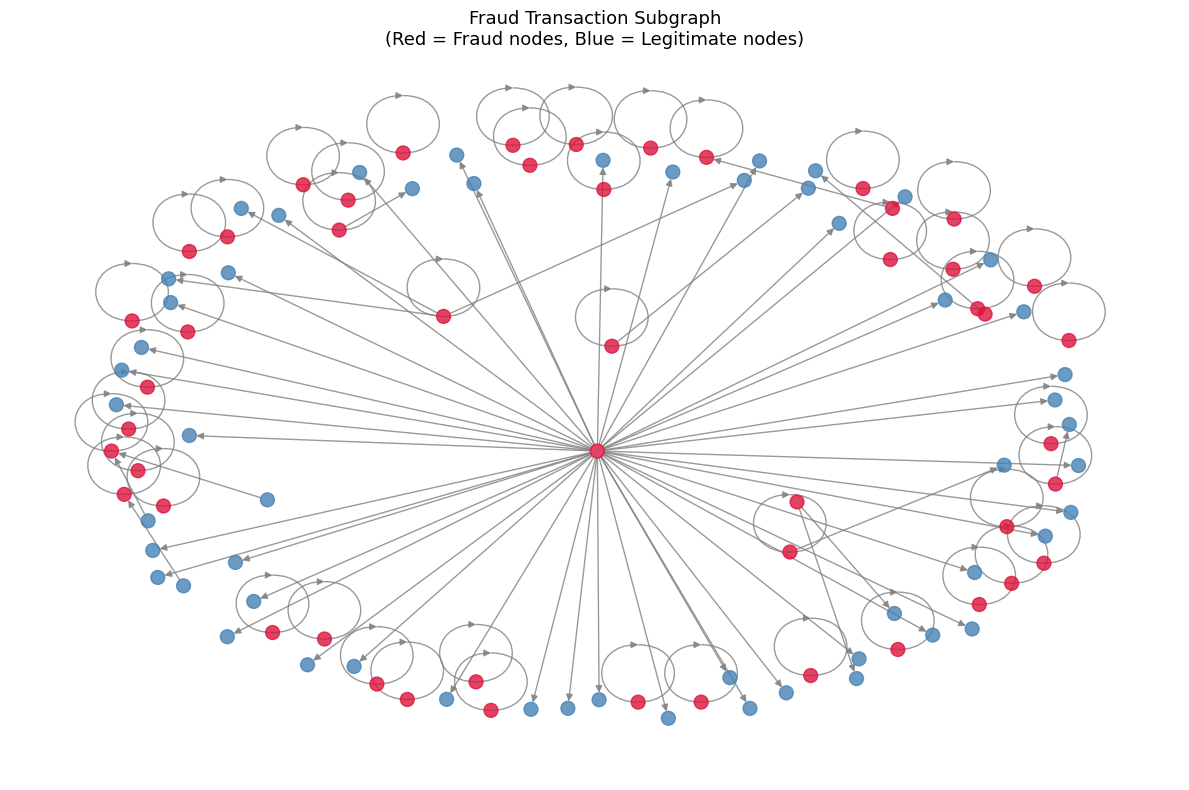

✅ Subgraph saved as fraud_subgraph.png


In [9]:
# Visualize a small piece of the graph
# (can't visualize all 5 lakh nodes — too big)

print("Building visualization of fraud subgraph...")

# Take only fraud nodes and their neighbors
fraud_node_indices = (y == 1).nonzero(as_tuple=True)[0][:50]  # first 50 fraud nodes

# Build small NetworkX graph for visualization
G = nx.DiGraph()

# Add edges involving fraud nodes
edge_src = edge_index[0].numpy()
edge_dst = edge_index[1].numpy()

fraud_set = set(fraud_node_indices.numpy())

for s, d in zip(edge_src[:5000], edge_dst[:5000]):
    if s in fraud_set or d in fraud_set:
        G.add_edge(s, d)

# Color: red = fraud, blue = legit
node_colors = []
for node in G.nodes():
    if node in fraud_set:
        node_colors.append('crimson')
    else:
        node_colors.append('steelblue')

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=100,
    font_size=6,
    arrows=True,
    edge_color='gray',
    alpha=0.8,
    with_labels=False
)
plt.title('Fraud Transaction Subgraph\n(Red = Fraud nodes, Blue = Legitimate nodes)', 
          fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('fraud_subgraph.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Subgraph saved as fraud_subgraph.png")

In [10]:
# Save graph to disk — we'll load this in the next notebook
import os
os.makedirs('outputs', exist_ok=True)

torch.save(data, 'outputs/ibm_graph.pt')

# Also save the scaler and mapping for later use
import pickle
with open('outputs/account_to_idx.pkl', 'wb') as f:
    pickle.dump(account_to_idx, f)

import joblib
joblib.dump(scaler, 'outputs/scaler.pkl')

print("✅ Graph saved to:   outputs/ibm_graph.pt")
print("✅ Mapping saved to: outputs/account_to_idx.pkl")
print("✅ Scaler saved to:  outputs/scaler.pkl")
print("\n🎉 Graph construction complete!")
print("   Ready for model training in next notebook.")

✅ Graph saved to:   outputs/ibm_graph.pt
✅ Mapping saved to: outputs/account_to_idx.pkl
✅ Scaler saved to:  outputs/scaler.pkl

🎉 Graph construction complete!
   Ready for model training in next notebook.
